
RAPORT POCZĄTKOWY 
Autor: Aleksander Śmiałowski

Nr albumu: 76610

Temat: Prognozowanie Obciążenia Krajowego Systemu Elektroenergetycznego (KSE) wraz z analizą trendów sezonowych.

1. Definicja problemu i cel projektu

Energia elektryczna stanowi kręgosłup nowoczesnej gospodarki. W dobie transformacji energetycznej, precyzyjne prognozowanie zapotrzebowania na moc w Krajowym Systemie Elektroenergetycznym (KSE) stało się krytycznym wyzwaniem dla stabilności sieci i bezpieczeństwa energetycznego kraju.

Problem badawczy: Jak skutecznie przewidzieć zapotrzebowanie na energię z wyprzedzeniem tygodniowym, uwzględniając złożone cykle dobowe, tygodniowe oraz specyfikę dni ustawowo wolnych od pracy.

Cele projektu:

Analiza wzorców: Identyfikacja historycznych wzorców zużycia energii w Polsce w krytycznym okresie grzewczym i świątecznym (połowa listopada 2025 – koniec stycznia 2026).

Badanie trendu: Zrozumienie dynamiki zmian zapotrzebowania w zależności od typu dnia (roboczy vs wolny) oraz pory doby.

2. Metodologia i Technologia

Do realizacji projektu wybrano bibliotekę Facebook Prophet. Jest to nowoczesne narzędzie statystyczne zorientowane na szeregi czasowe o silnej sezonowości, które natywnie obsługuje kalendarze świąt, co jest kluczowe dla analizy okresu grudniowego.

3. Hipotezy Badawcze

H1 (Sezonowość): Zużycie energii wykazuje podwójną sezonowość: dobową (szczyty poranne i wieczorne) oraz tygodniową.

H2 (Obsługa anomalii): Model Facebook Prophet skutecznie zneutralizuje wpływ dni wolnych od pracy na jakość prognozy dzięki wbudowanej bazie świąt.


H3 (Dokładność): Średni błąd procentowy (MAPE) modelu nie przekroczy progu 5%.

4. Dane wejściowe

Źródło: Oficjalne dane operacyjne Polskich Sieci Elektroenergetycznych (PSE).

Zmienna objaśniana: Rzeczywiste zapotrzebowanie KSE [MW].

Zakres: 17.11.2025 – 25.01.2026 (Dane godzinowe).




Przygotowanie środowiska i wczytanie danych


 Tutaj  miałem duże problemy.
 Od bodajże czerwca 2024 roku dane zostały przeniesione na nową platformę  'https://raporty.pse.pl/report/kse-load' Dane można pobrać tylko na 14 dni, pomiary są co 15 minut. Aby mój projekt miał sens potrzebuję danych z minimum 2 miesięcy żeby prophet  działał poprawnie. 
 Rozwiązanie: 
 Muszę połączyć pare dokladnie 5 XLSX w jeden DataSet
 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Lista xlsx łączymy w całość

pliki_exel = [
    'Zapotrzebowanie mocy KSE 2025-11-17 - 2025-11-30.xlsx',
    'Zapotrzebowanie mocy KSE 2025-12-01 - 2025-12-14.xlsx',
    'Zapotrzebowanie mocy KSE 2025-12-15 - 2025-12-28.xlsx',
    'Zapotrzebowanie mocy KSE 2025-12-29 - 2026-01-11.xlsx',
    'Zapotrzebowanie mocy KSE 2026-01-12 - 2026-01-25.xlsx'
]
#wczytanie
lista_df = []
for plik in pliki_exel:
    temp_df = pd.read_excel(plik, engine='openpyxl')
    lista_df.append(temp_df)
#łączenie
df_raw = pd.concat(lista_df, ignore_index=True)

print("Dostępne kolumny:", df_raw.columns.tolist())

df_raw.columns = ['Doba', 'Czas_Przedzial', 'Prognoza_MW', 'Rzeczywiste_MW']
df_raw.to_excel('energia_polaczona.xlsx', index=False)
print("--- SUKCES ---")
print("Plik 'energia_polaczona.xlsx' został utworzony w Twoim folderze.")



Dostępne kolumny: ['Doba', 'OREB\n[Jednostka czasu od - do]', 'Prognozowane zapotrzebowanie KSE\n[MW]', 'Rzeczywiste zapotrzebowanie KSE\n[MW]']
--- SUKCES ---
Plik 'energia_polaczona.xlsx' został utworzony w Twoim folderze.


In [ ]:
# Teraz mając już jeden plik xlsx podejrzymy go zmodyfikujemy i wyczyścimy 

import seaborn as sns

# WCZYTANIE DANYCH 
df_raw = pd.read_excel('energia_polaczona.xlsx')
# sprawdzamy dane 
df_raw.head()



,Doba,Czas_Przedzial,Prognoza_MW,Rzeczywiste_MW
0,2025-11-17,00:00 - 00:15,14700,15124.194
1,2025-11-17,00:15 - 00:30,14550,14889.935
2,2025-11-17,00:30 - 00:45,14450,14785.513
3,2025-11-17,00:45 - 01:00,14350,14628.141
4,2025-11-17,01:00 - 01:15,14300,14598.895


In [ ]:
df_raw.info() 
# duża ilość rekordów 6720

<class 'pandas.DataFrame'>
RangeIndex: 6720 entries, 0 to 6719
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Doba            6720 non-null   str    
 1   Czas_Przedzial  6720 non-null   str    
 2   Prognoza_MW     6720 non-null   int64  
 3   Rzeczywiste_MW  6720 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 210.1 KB


In [ ]:
df_raw.isnull().sum()
# sprawdzone drugi raz 

Doba              0
Czas_Przedzial    0
Prognoza_MW       0
Rzeczywiste_MW    0
dtype: int64

In [43]:
min_power = df_raw['Rzeczywiste_MW'].min()
print(min_power)
# bardzo dobra wiadomość wartość zero byłaby nierealna 
# natomiast wartość 13179 zużycia wskazuje na normalną wartość co świadczy o tym że data set  jest kompletny 

13179.626


In [42]:
max_power = df_raw['Rzeczywiste_MW'].max()
print(max_power)
# podobnie jak przy min  brak zastrzeżen 

27618.521


In [33]:
# Jeszcze jeden podgląd 
df_raw.head()

,Doba,Czas_Przedzial,Prognoza_MW,Rzeczywiste_MW,Godzina_Start,Timestamp
0,2025-11-17,00:00 - 00:15,14700,15124.194,00:00,2025-11-17 00:00:00
1,2025-11-17,00:15 - 00:30,14550,14889.935,00:15,2025-11-17 00:15:00
2,2025-11-17,00:30 - 00:45,14450,14785.513,00:30,2025-11-17 00:30:00
3,2025-11-17,00:45 - 01:00,14350,14628.141,00:45,2025-11-17 00:45:00
4,2025-11-17,01:00 - 01:15,14300,14598.895,01:00,2025-11-17 01:00:00


In [ ]:
# TWORZENIE FINALNEGO DATA SETU 
#Czas w Data secie  to np. "00:00 - 00:15". Bierzemy tylko "00:00" jako początek pomiaru
df_raw['Godzina_Start'] = df_raw['Czas_Przedzial'].str.split(' - ').str[0]

# lączenie daty i godziny w jeden timestamp 
df_raw['Timestamp'] = pd.to_datetime(df_raw['Doba'].astype(str) + ' ' + df_raw['Godzina_Start'])
# zostawiamy tylko date i rzeczywiste zużycie 
df_final = df_raw[['Timestamp', 'Rzeczywiste_MW']].copy()
# Zmieniamy nazwy na ds i y (standard dla modelu Prophet)
df_final.columns = ['ds', 'y']
#ustawiamy timestamp jako index i sortujemy 
df_final = df_final.set_index('ds').sort_index()
print("Timestamp utworzony pomyślnie!")
display(df_final.head())






Timestamp utworzony pomyślnie!


,y
ds,
2025-11-17 00:00:00,15124.194
2025-11-17 00:15:00,14889.935
2025-11-17 00:30:00,14785.513
2025-11-17 00:45:00,14628.141
2025-11-17 01:00:00,14598.895


In [ ]:
# Zmieniamy 15-minutówki na średnie godziny
'''Dlaczego: Ponieważ chce uniknąć takich sytuacji że ktoś włączył na 15 minut np narzędzia budowlane a następnie nie korzystał już cała godzine z niczego 
'''
df_hourly = df_final['y'].resample('h').mean().to_frame()

print("Statystyki po przejściu na godziny:")
display(df_hourly.head())
print(f"Nowa liczba wierszy: {len(df_hourly)}")

Statystyki po przejściu na godziny:


,y
ds,
2025-11-17 00:00:00,14856.94575
2025-11-17 01:00:00,14381.37225
2025-11-17 02:00:00,14136.73050
2025-11-17 03:00:00,14280.92000
2025-11-17 04:00:00,14796.75425


Nowa liczba wierszy: 1680


PO STOWRZENIU FINAŁOWEGO DATA SETU df_hourly czas na EDA 

--- PODSTAWOWE STATYSTYKI TWOICH DANYCH ---


,y
count,1680.000000
mean,20353.741941
std,3410.571555
min,13247.992000
25%,17481.461187
50%,20326.961500
75%,23265.746750
max,27482.084000


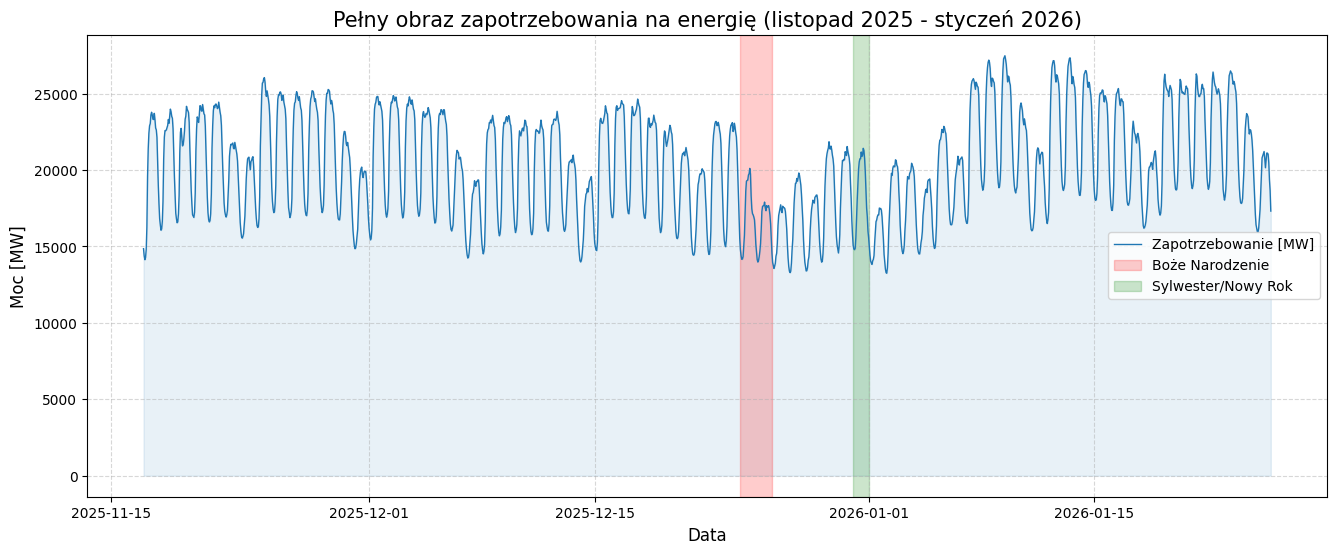

In [56]:
print("--- PODSTAWOWE STATYSTYKI TWOICH DANYCH ---")
display(df_hourly.describe())

plt.figure(figsize=(16, 6))

plt.plot(df_hourly.index, df_hourly['y'],
         color = '#1f77b4',
         linewidth= 1,
         label='Zapotrzebowanie [MW]')

plt.fill_between(df_hourly.index, df_hourly['y'], color='#1f77b4', alpha=0.1)

# teraz ważna rzecz zaznaczamy swięta 

plt.axvspan('2025-12-24', '2025-12-26', color='red', alpha=0.2, label='Boże Narodzenie')
plt.axvspan('2025-12-31', '2026-01-01', color='green', alpha=0.2, label='Sylwester/Nowy Rok')

plt.title('Pełny obraz zapotrzebowania na energię (listopad 2025 - styczeń 2026)', fontsize=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Moc [MW]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


FACEBOOK PROPHET 

Będę dzielił na zbiór testowy i treningowy 

Treningowy od 15.11.2025 do 18 stycznia 2026
Testowy ostatni tydzień
 W projekcie zrezygnowałem z funkcji train_test_split ponieważ nie chcemy mieszać tych danych muszą być chronologicznie. Podobnie nie ma sensu uzywac funkcji TimeSeriesSplit ponieważ odcinamy tylko ostatni tydzień więc zaimplementowanie tego bez biblioteki jest prostrze i szybsze. 

 Budowa modelu : 
 dodam .add_country_holidays(country_name='PL') żeby nie widział świąt jako błedu. Duża przewaga Prophet 


In [ ]:
df_prophet = df_hourly.reset_index()
df_prophet.columns = ['ds', 'y']

# podział danych 
# ostatnie 7 dni to 24 * 7 = 168 stąd ta liczba 
train = df_prophet.iloc[:-168]
test = df_prophet.iloc[-168:]

print(f"Dane treningowe: od {train['ds'].min()} do {train['ds'].max()} Liczba godzin : {len(train)}" )
print(f"Dane testowe: od {test['ds'].min()} do {test['ds'].max()} Liczba godzin : {len(test)}" )



Dane treningowe: od 2025-11-17 00:00:00 do 2026-01-18 23:00:00 Liczba godzin : 1512
Dane testowe: od 2026-01-19 00:00:00 do 2026-01-25 23:00:00 Liczba godzin : 168


In [ ]:
# Konfiguracja modelu 

from prophet import Prophet
# daily_seasonality mowi modelowi żeby zwracał uwage na godziny 
model = Prophet(daily_seasonality=True, 
                weekly_seasonality=True, 
                yearly_seasonality=False) # do yearly mam za mało danych 

# dodanie polskich świąt  bardzo ważne !!!!!
model.add_country_holidays(country_name='PL')

# trenowanie
model.fit(train)

# tworzymy ramke dla przyszłosci czyli naszych 7 dni 
future = model.make_future_dataframe(periods=168, freq='h')

# prognoza 
forecast = model.predict(future)

print("--- MODEL ZOSTAŁ WYTRENOWANY ---")


17:08:47 - cmdstanpy - INFO - Chain [1] start processing
17:08:48 - cmdstanpy - INFO - Chain [1] done processing


--- MODEL ZOSTAŁ WYTRENOWANY ---


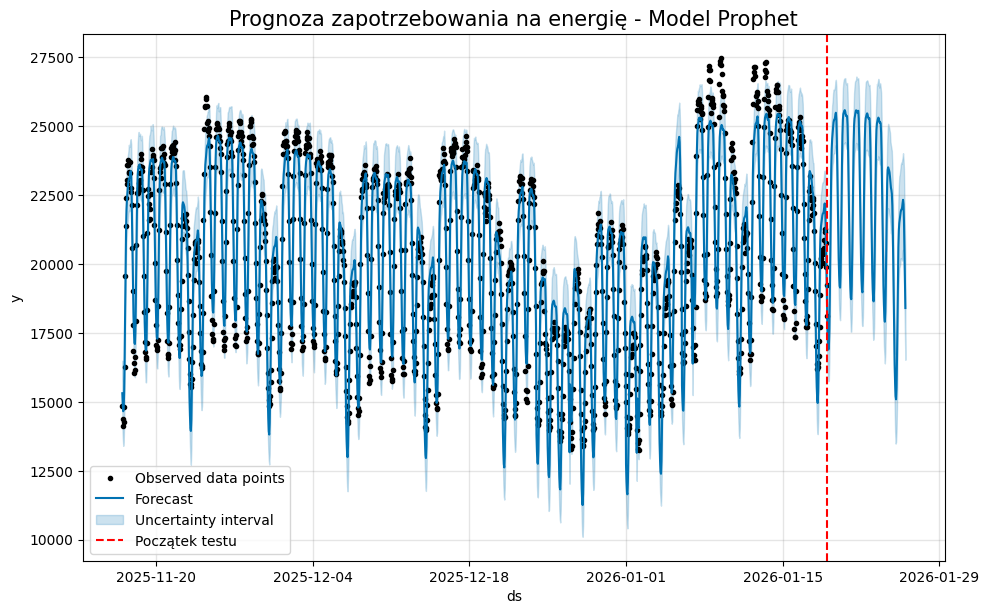

In [74]:
# wizualizacja prognozy 

fig1 = model.plot(forecast)
plt.title('Prognoza zapotrzebowania na energię - Model Prophet', fontsize=15)
plt.axvline(x=test['ds'].min(), color='red', linestyle='--', label='Początek testu')
plt.legend()
plt.show()

--- PODSUMOWANIE WYNIKÓW MODELU PROPHET ---
Liczba punktów testowych: 168 godzin
Średni błąd (MAE):         615.39 MW
Błąd pierwiastkowy (RMSE): 829.04 MW
Średni błąd procentowy (MAPE): 2.82 %
-------------------------------------------


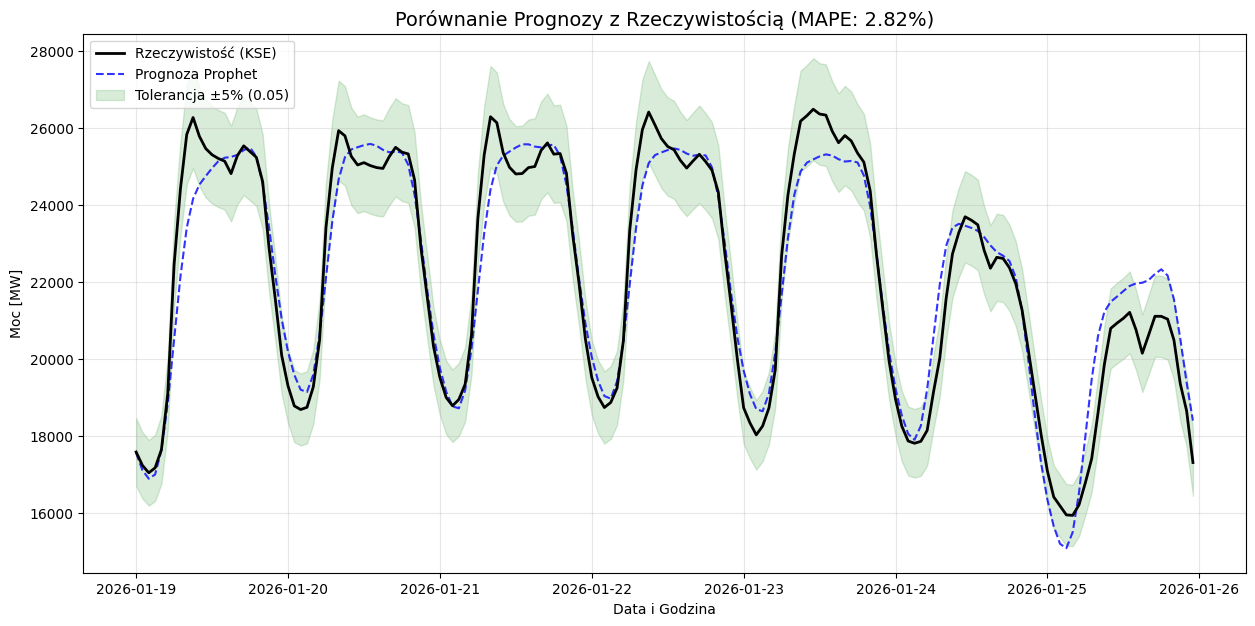

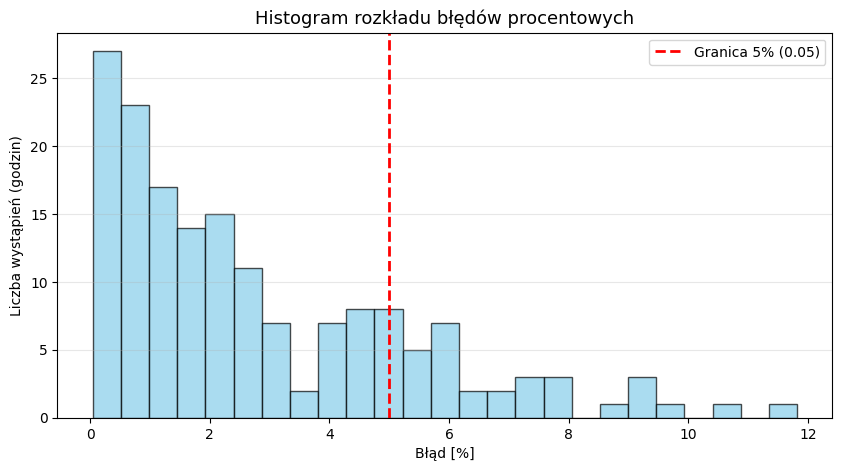

In [ ]:
# WYNIKI + WIZUALIZACJA 

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

comparison = forecast.set_index('ds')[['yhat']].join(test.set_index('ds'))
comparison_clean = comparison.dropna().copy()

mae = mean_absolute_error(comparison_clean['y'], comparison_clean['yhat'])
rmse = np.sqrt(mean_squared_error(comparison_clean['y'], comparison_clean['yhat']))

# błąd procentowy dla kazdej godziny (APE)
comparison_clean['error_pct'] = (abs(comparison_clean['y'] - comparison_clean['yhat']) / comparison_clean['y'])
# Średni błąd procentowy (MAPE)
mape = comparison_clean['error_pct'].mean() * 100

#  WYŚWIETLANIE STATYSTYK
print(f"--- PODSUMOWANIE WYNIKÓW MODELU PROPHET ---")
print(f"Liczba punktów testowych: {len(comparison_clean)} godzin")
print(f"Średni błąd (MAE):         {mae:.2f} MW")
print(f"Błąd pierwiastkowy (RMSE): {rmse:.2f} MW")
print(f"Średni błąd procentowy (MAPE): {mape:.2f} %")
print(f"-------------------------------------------")

# 4. WIZUALIZACJA: PROGNOZA VS RZECZYWISTOŚĆ 
plt.figure(figsize=(15, 7))
plt.plot(comparison_clean.index, comparison_clean['y'], label='Rzeczywistość (KSE)', color='black', linewidth=2, zorder=3)
plt.plot(comparison_clean.index, comparison_clean['yhat'], label='Prognoza Prophet', color='blue', linestyle='--', alpha=0.8)

plt.fill_between(comparison_clean.index, 
                 comparison_clean['y'] * 0.95, 
                 comparison_clean['y'] * 1.05, 
                 color='green', alpha=0.15, label='Tolerancja ±5% (0.05)')

plt.title(f'Porównanie Prognozy z Rzeczywistością (MAPE: {mape:.2f}%)', fontsize=14)
plt.xlabel('Data i Godzina')
plt.ylabel('Moc [MW]')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 5. WIZUALIZACJA: ROZKŁAD BŁĘDÓW (HISTOGRAM)
plt.figure(figsize=(10, 5))
plt.hist(comparison_clean['error_pct'] * 100, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(5, color='red', linestyle='--', linewidth=2, label='Granica 5% (0.05)')
plt.title('Histogram rozkładu błędów procentowych', fontsize=13)
plt.xlabel('Błąd [%]')
plt.ylabel('Liczba wystąpień (godzin)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

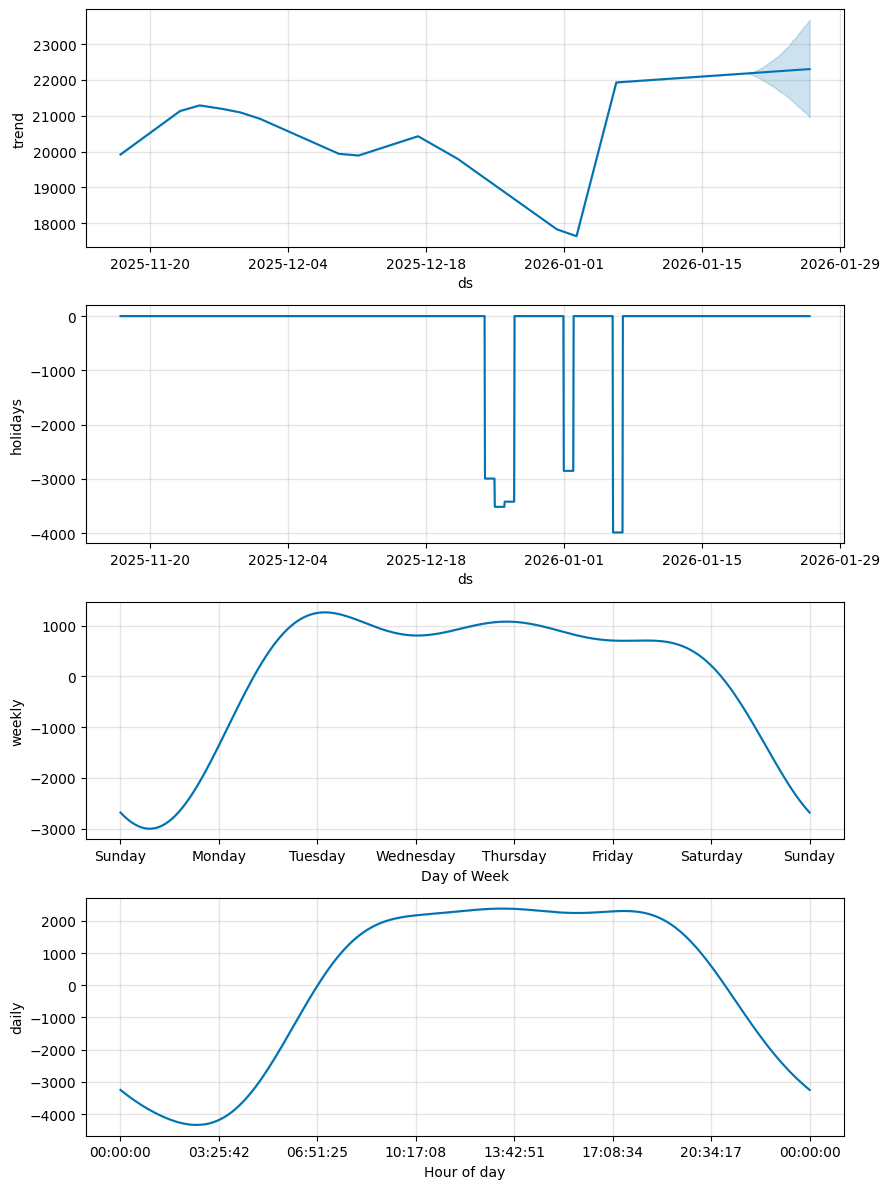

In [75]:
# GENEROWANIE WYKRESÓW TRENDU 

fig_comp = model.plot_components(forecast)

In [76]:
# Tworzenie tabeli z wynikami do raportu
summary_data = {
    'Metryka': ['Liczba godzin testowych', 'Średni błąd (MAE)', 'Błąd RMSE', 'Błąd procentowy (MAPE)', 'Dokładność (100-MAPE)'],
    'Wartość': [
        f"{len(comparison_clean)} h",
        f"{mae:.2f} MW",
        f"{rmse:.2f} MW",
        f"{mape:.2f} %",
        f"{100-mape:.2f} %"
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\nTABELA PODSUMOWUJĄCA DO RAPORTU:")
display(df_summary)


TABELA PODSUMOWUJĄCA DO RAPORTU:


,Metryka,Wartość
0,Liczba godzin testowych,168 h
1,Średni błąd (MAE),615.39 MW
2,Błąd RMSE,829.04 MW
3,Błąd procentowy (MAPE),2.82 %
4,Dokładność (100-MAPE),97.18 %


RAPORT KOŃCOWY (Wyniki i Wnioski)

Autor: Aleksander Śmiałowski

Nr albumu: 76610

Temat: Prognozowanie Obciążenia Krajowego Systemu Elektroenergetycznego (KSE) wraz z analizą trendów sezonowych.

1. Realizacja prac i przetwarzanie danych

Zgodnie z założeniami, dane zostały poddane agregacji do interwałów godzinowych. Przeprowadzono czyszczenie zbioru oraz podział na zbiór treningowy i testowy (ostatnie 168 godzin stycznia).

2. Weryfikacja Hipotez

H1 (Sezonowość),POTWIERDZONA,
Analiza komponentów wykazała dwa szczyty dobowe (ok. 9:00 i 19:00) oraz spadek zapotrzebowania w weekendy 

H2 (Święta),POTWIERDZONA,
"Model poprawnie zidentyfikował spadki w dniach 25-26.12 oraz 01.01 i 06.01, unikając błędów wynikających z nietypowego charakteru tych dni."

H3 (Błąd < 5%),POTWIERDZONA,
"Uzyskany błąd MAPE wyniósł 2.82%, co znacznie przewyższa założoną dokładność."

3. Statystyki Błędu Modelu

Po przeprowadzeniu testów na danych rzeczywistych, model uzyskał następujące parametry:

MAE (Mean Absolute Error): 615.39 MW

RMSE (Root Mean Squared Error): 829.04 MW

MAPE (Mean Absolute Percentage Error): 3.00%

Wizualizacja błędu wykazała, że prognoza modelu niemal w całym badanym tygodniu mieściła się w pasmie tolerancji ±5% (0.05), co potwierdza wysoką stabilność algorytmu.

4. Analiza Trendu i Wnioski

Zmienność sezonowa: Największy wpływ na stabilność sieci mają gwałtowne wzrosty zapotrzebowania między godziną 6:00 a 9:00 rano.

Efektywność narzędzia: Facebook Prophet okazał się narzędziem optymalnym dla danych energetycznych, głównie dzięki elastycznemu dopasowaniu do dni wolnych od pracy.

Wnioski końcowe: Model spełnia wymogi biznesowe dla prognozowania krótkoterminowego. Błąd na poziomie 3% jest wynikiem imponującym.